In [1]:
import numpy as np
from collections import defaultdict
from sklearn.cluster import KMeans
import re,glob,gzip
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import ks_2samp

#cmap = cm.coolwarm
cdict1 = {'red':   ((0.0, 0.0, 0.0),
                   (0.5, 0.0, 0.1),
                   (1.0, 1.0, 1.0)),

         'green': ((0.0, 0.0, 0.0),
                   (1.0, 0.0, 0.0)),

         'blue':  ((0.0, 0.0, 1.0),
                   (0.5, 0.1, 0.0),
                   (1.0, 0.0, 0.0))
        }
bluered1 = LinearSegmentedColormap('BlueRed1', cdict1)
cmap = bluered1
%matplotlib inline

# MS vs. control

## DMR only

In [212]:
##get label dict
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    testing_label_list=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    



In [213]:
##get sample matrix dict
import math
from sklearn.impute import KNNImputer

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

#imputer = KNNImputer(n_neighbors=10)

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    #training_mat_list = stats.zscore(training_mat_list,nan_policy='omit')
    #training_mat_list_after_imputation = imputer.fit_transform(training_mat_list)
    #training_sample_mat_dict[fold]=training_mat_list_after_imputation
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    #testing_mat_list = stats.zscore(testing_mat_list,nan_policy='omit')
    #testing_mat_list_after_imputation = imputer.fit_transform(testing_mat_list)
    #testing_sample_mat_dict[fold]=testing_mat_list_after_imputation
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/275

0.9166666666666667
0.5
0.8
0.9166666666666667
0.8333333333333334
0.6
1.0
1.0
0.6
0.9166666666666667


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/2759625904.py:51: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


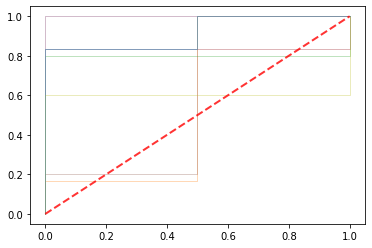

In [216]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD


random_state=42




tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


for i in range(10):
    svd = TruncatedSVD(n_components=2, random_state=random_state)

    train_dmr_X = training_sample_mat_dict[i].transpose()
    train_dmr_SVD = svd.fit_transform(train_dmr_X)
    
    train_y = training_sample_label_dict[i]
    
    test_dmr_X = testing_sample_mat_dict[i].transpose()
    test_dmr_SVD = svd.transform(test_dmr_X)
    
    test_y = testing_sample_label_dict[i]
    
    random_state_i = random_state + i
    
   
    classifier = LogisticRegression(penalty='l2', dual=False, tol=1e-5, C=120, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=1000, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)

    classifier.fit(train_dmr_SVD, train_y)
    final_prob_test = classifier.predict_proba(test_dmr_SVD)[:, 1]

    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, final_prob_test)
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



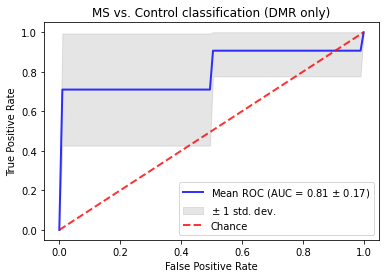

In [218]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Control classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/performance_model.ms_vs_control_CV.top2_SVD.logis_l2.pdf", bbox_inches='tight')



## TOO only

In [813]:
##get dictionary of TOO matrix for each sample
too_mat_dict=dict()

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/too/too_plus_names.uxm_res.75_samples.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        sample_name = splitline[0]
        too_mat_dict[sample_name]=np.array(splitline[2:],dtype='float32')

##get dictionary for subtype
sample_group_dict=dict()

with open('/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control_table_design_matrix.75samples.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        if splitline[1] == 'base':
                continue
        sample_name = splitline[0]
        sample_group_dict[sample_name]=np.array(splitline[5],dtype='int32')


##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/ms_vs_control_table_design_matrix.bin.v2.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    

##get sample matrix dict
import math

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/ms_vs_control/dmrs.ms_vs_control.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



In [897]:
# 2) Define a function for Mann–Whitney one-sided test, returning True if p<0.05
def is_significant_one_sided(feature_values, labels, cutoff=0.05):
    """
    feature_values: array of shape (n_train,) for the training fold
    labels: array of shape (n_train,) with 0 or 1
    We'll do:
       - median( group0 ) vs median( group1 )
       - if median( group0 ) < median( group1 ): alternative='less'
         else alternative='greater'
    returns (bool, p_value) => (whether p<0.05, actual p)
    """
    group0 = feature_values[labels == 0]
    group1 = feature_values[labels == 1]
    if len(group0)==0 or len(group1)==0:
        # fallback: can't do test if one group is empty
        return False, 1.0

    med0 = np.median(group0)
    med1 = np.median(group1)
    # decide direction
    alt = "less" if med0 < med1 else "greater"

    res = stats.mannwhitneyu(group0, group1, alternative=alt)
    #res = stats.mannwhitneyu(group0, group1)
    pval = res.pvalue
    return (pval < cutoff), pval

In [173]:
def is_significant_one_sided_4groups_allsubsets(feature_values, labels, cutoff=0.05):
    """
    Given feature_values (an array, each entry a sample's value) and labels (in {1,2,3,4}),
    perform the following comparisons using one-sided Mann–Whitney:
      - All non-empty proper subsets S of {1,2,3,4} vs. their complement S^c
        (i.e. S vs. S^c).
        We skip duplicates by ensuring mask < (15 - mask) for 4 groups => skip reversed.
      - If any comparison has p < 0.05, return (True, min_p).
      - Otherwise (False, max_p).

    The direction ("less" or "greater") is chosen by comparing medians:
      if median(S) < median(S^c) => alternative="less"
      else => "greater".

    Parameters
    ----------
    feature_values : 1D array of shape (n_samples,)
        The numeric values for a single feature across all samples
    labels : 1D array of shape (n_samples,) in {1,2,3,4}
        Indicating which group each sample belongs to

    Returns
    -------
    (is_sig, p_min)
      is_sig : bool
          True if any subset vs. complement yields p < 0.05
      p_min : float
          The smallest p-value found across all tested comparisons
    """
    # Split data by group
    group1 = feature_values[labels == 1]
    group2 = feature_values[labels == 2]
    group3 = feature_values[labels == 3]
    group4 = feature_values[labels == 4]

    # Helper to combine an index set (like [1,2]) into the corresponding data
    def combine_data_for_subset(index_set):
        combined = []
        for idx in index_set:
            if idx == 1:
                combined.append(group1)
            elif idx == 2:
                combined.append(group2)
            elif idx == 3:
                combined.append(group3)
            elif idx == 4:
                combined.append(group4)
        if len(combined) == 0:
            return np.array([])
        return np.concatenate(combined)

    # One-sided test function
    def one_sided_mw_test(arrA, arrB):
        if len(arrA) == 0 or len(arrB) == 0:
            return 1.0  # can't do meaningful test
        medA = np.median(arrA)
        medB = np.median(arrB)
        alt = "less" if medA < medB else "greater"
        res = stats.mannwhitneyu(arrA, arrB, alternative=alt)
        #res = stats.mannwhitneyu(arrA, arrB)
        return res.pvalue

    # We'll store p-values
    pvals = []

    # For enumerating subsets of {1,2,3,4}, we use bitmasks from 1..(2^4-1) => 1..15
    # skip empty set (mask=0) or full set (mask=15)
    # also skip reversed duplicates => only do if mask < (15 - mask).
    # i.e. S vs. S^c is same as S^c vs. S reversed
    for mask in range(1, 16):  # 1..15
        if mask == 15:  # full set
            continue
        complement = 15 - mask  # bitwise complement in 4 bits => 1111 - mask
        if mask < complement:
            # define subset S
            S = []
            for bitpos in range(4):  # 0..3
                # check if bit is set
                # if labels are 1..4 => we do bitpos+1
                if (mask & (1 << bitpos)) != 0:
                    S.append(bitpos+1)

            if len(S) == 0 or len(S) == 4:
                continue

            # define S^c
            # For 4 groups, that's simply set {1,2,3,4} minus S
            # but we can do the bit approach or standard python set approach
            # but we already know complement = ...
            # We'll just do a python set difference
            fullset = {1,2,3,4}
            S_c = list(fullset.difference(S))

            arrS   = combine_data_for_subset(S)
            arrSc  = combine_data_for_subset(S_c)

            pval = one_sided_mw_test(arrS, arrSc)
            pvals.append(pval)

    # If you specifically want the 6 pairwise single-group comparisons, e.g. (1 vs 2), (1 vs 3), etc.
    # ignoring other groups, do it here:
    pairwise_groups = [(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]
    for (gA, gB) in pairwise_groups:
        arrA = combine_data_for_subset([gA])  # just group gA
        arrB = combine_data_for_subset([gB])  # just group gB
        pval = one_sided_mw_test(arrA, arrB)
        pvals.append(pval)

    # Now we have a list of pvals from all subset vs complement and all pairwise single-group
    if len(pvals) == 0:
        return (False, 1.0)  # no comparisons done
    p_min = np.min(pvals)
    is_sig = (p_min < cutoff)
    return (is_sig, p_min)

Number of features selected: (67, 6)
Number of features selected: (67, 5)
Number of features selected: (68, 6)
Number of features selected: (67, 3)
Number of features selected: (68, 5)
Number of features selected: (68, 6)
Number of features selected: (67, 4)
Number of features selected: (67, 5)
Number of features selected: (69, 5)
Number of features selected: (67, 4)


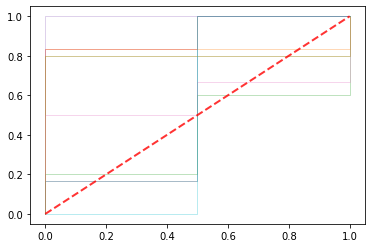

In [814]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
index = [2,3,4,5,6,12,22,23,30]
#X = ms_control_mat[:,index]
#y = ms_control_label

ms_control_too_mask_dict=dict()
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = GradientBoostingClassifier(n_estimators=200, learning_rate=0.2, max_depth=10, random_state=random_state,min_samples_split=2,min_samples_leaf=1,subsample=0.8,max_features='log2')

    n_features = train_X.shape[1]
    ms_groups_train = training_sample_group_dict[i]

    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided_4groups_allsubsets(col_values, ms_groups_train, 0.05)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    # select these features
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    ms_control_too_mask_dict[i]=significance_mask
    print("Number of features selected:", train_X[:, significance_mask].shape)
    #print(np.array(pvals))
    # Step C: Fit classifier on selected features
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




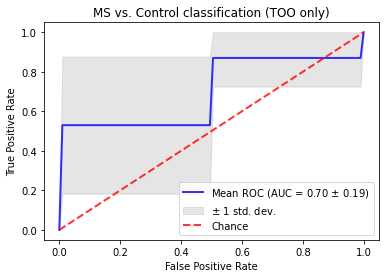

In [815]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MS vs. Control classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
#f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.diff_too_neuron_immune.ms_vs_control_CV.gbt.pdf", bbox_inches='tight')


# Progressive MS vs. RRMS

## DMR only (Progressive MS vs. RRMS)

In [4]:
# ─── Shared setup for subtype comparisons ────────────────────────────────────
import gzip, math, os, bisect, warnings
from collections import defaultdict
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_selection import RFECV
from sklearn.base import clone
from sklearn import svm
from lightgbm import LGBMClassifier
import xgboost
import matplotlib.pyplot as plt
import numpy as np
warnings.filterwarnings('ignore')

BASE_REV = ("/Users/pfu2606/Library/CloudStorage/OneDrive-NorthwesternUniversity"
            "/MS project/paper revision")
BASE_SUB = os.path.join(BASE_REV, "fixed subtypes")

TOO_FILE     = os.path.join(BASE_SUB, "too_plus_names.uxm_res.75_samples.v3.txt")
METHY_FILE   = os.path.join(BASE_REV, "dmrs.merged_subtypes.add_value.methy.bed.gz")
NAMES_FILE   = os.path.join(BASE_REV, "names_order.ms_vs_control.txt")
FOLD_DIR_PVR = os.path.join(BASE_SUB, "dmr", "10_fold", "progressive_vs_rrms")
FOLD_DIR_AVS = os.path.join(BASE_SUB, "dmr", "10_fold", "active_vs_stable")

random_state = 42
MEAN_FPR     = np.linspace(0, 1, 100)
TOO_IDX      = [2, 3, 4, 5, 6, 12, 22, 23, 30]

# Load TOO fractions and subtype group codes
too_dict   = {}
group_dict = {}
with open(TOO_FILE) as f:
    for line in f:
        p = line.rstrip('\n').split('\t')
        too_dict[p[0]]   = np.array(p[2:], dtype='float32')
        group_dict[p[0]] = int(p[1])

# Load sample order for methylation matrix columns
sample_order = []
with open(NAMES_FILE) as f:
    for line in f:
        p = line.rstrip('\n').split('\t')
        sample_order.append(p[1])
full_to_idx = {s: i for i, s in enumerate(sample_order)}

# Load methylation matrix
methy_rownames, methy_vals = [], []
with gzip.open(METHY_FILE, 'rt') as f:
    for line in f:
        p = line.rstrip('\n').split('\t')
        methy_rownames.append(p[3])
        vals = [np.nan if math.isclose(float(p[i+1]), 0, abs_tol=1e-9)
                else float(p[i]) / float(p[i+1])
                for i in range(6, len(p), 2)]
        methy_vals.append(np.array(vals, dtype='float32'))
methy_mat        = np.nan_to_num(np.array(methy_vals, dtype='float32'))
methy_key_to_row = {rid: i for i, rid in enumerate(methy_rownames)}

# Interval index for DMR overlap lookup
chrom_intervals = defaultdict(list)
for rid, row_idx in methy_key_to_row.items():
    chrom, coords = rid.split(':')
    s, e = coords.split('-')
    chrom_intervals[chrom].append((int(s), int(e), row_idx))
for chrom in chrom_intervals:
    chrom_intervals[chrom].sort()

def find_overlapping_rows(chrom, qstart, qend):
    ivs = chrom_intervals.get(chrom, [])
    if not ivs: return []
    starts = [iv[0] for iv in ivs]
    lo = bisect.bisect_left(starts, qend)
    result = []
    for i in range(lo - 1, -1, -1):
        s, e, ri = ivs[i]
        if e <= qstart: break
        if s < qend and e > qstart: result.append(ri)
    for i in range(lo, len(ivs)):
        s, e, ri = ivs[i]
        if s >= qend: break
        if s < qend and e > qstart: result.append(ri)
    return result

def get_dmr_row_indices(bed_path):
    seen = set(); indices = []
    with open(bed_path) as f:
        for line in f:
            p = line.rstrip('\n').split('\t')
            chrom = p[0].replace('chr', '')
            for ri in find_overlapping_rows(chrom, int(p[1]), int(p[2])):
                if ri not in seen:
                    seen.add(ri); indices.append(ri)
    return indices

def load_fold_samples(path):
    names, labels = [], []
    with open(path) as f:
        for line in f:
            p = line.rstrip('\n').split('\t')
            if p[1] == 'base': continue
            names.append(p[0].replace('.meth', ''))
            labels.append(int(p[3]))
    return names, np.array(labels, dtype='int32')

def short_name(full):
    return full.split('.')[-1]

print("Setup complete.")
print(f"  TOO: {len(too_dict)} samples")
print(f"  Methylation: {methy_mat.shape[0]} regions x {methy_mat.shape[1]} samples")


Setup complete.
  TOO: 75 samples
  Methylation: 1401 regions x 75 samples


In [5]:
# PMS vs. RRMS — DMR only (LGBMClassifier + RFECV)
# pvr_fold_dmr stores selected DMR features per fold for use in DMR+TOO cell
pvr_fold_dmr = {}
tprs_pvr_dmr, aucs_pvr_dmr = [], []
cv10 = StratifiedKFold(n_splits=10)

for fold_i in range(10):
    tr_names, tr_labels = load_fold_samples(os.path.join(FOLD_DIR_PVR,
        f"progressive_vs_rrms_table_design_matrix.bin.v2.training.fold{fold_i:02d}"))
    te_names, te_labels = load_fold_samples(os.path.join(FOLD_DIR_PVR,
        f"progressive_vs_rrms_table_design_matrix.bin.v2.testing.fold{fold_i:02d}"))
    tr_keep = [s in full_to_idx for s in tr_names]
    te_keep = [s in full_to_idx for s in te_names]
    tr_cols   = np.array([full_to_idx[s] for s in tr_names if s in full_to_idx])
    te_cols   = np.array([full_to_idx[s] for s in te_names if s in full_to_idx])
    tr_labels = tr_labels[tr_keep]; te_labels = te_labels[te_keep]
    tr_names  = [s for s in tr_names if s in full_to_idx]
    te_names  = [s for s in te_names if s in full_to_idx]

    dmr_rows = get_dmr_row_indices(os.path.join(FOLD_DIR_PVR,
        f"dmrs.progressive_vs_rrms.fold{fold_i:02d}.adjusted.bed"))
    rows = np.array(dmr_rows)
    X_train = methy_mat[rows, :][:, tr_cols].T
    X_test  = methy_mat[rows, :][:, te_cols].T

    base_clf = LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31,
                               max_depth=-1, reg_alpha=0.1, reg_lambda=0.1,
                               subsample=0.8, colsample_bytree=0.8,
                               min_child_samples=10, verbose=-1)
    rfecv = RFECV(estimator=base_clf, step=1, cv=cv10, scoring='accuracy',
                  min_features_to_select=1, n_jobs=-1)
    rfecv.fit(X_train, tr_labels)
    print(f"  fold {fold_i}: {len(dmr_rows)} DMR regions, {rfecv.n_features_} selected")
    clf = clone(base_clf)
    clf.fit(X_train[:, rfecv.support_], tr_labels)
    prob = clf.predict_proba(X_test[:, rfecv.support_])[:, 1]

    pvr_fold_dmr[fold_i] = {
        'tr_labels': tr_labels, 'te_labels': te_labels,
        'tr_names': tr_names,   'te_names': te_names,
        'dmr_X_train': X_train[:, rfecv.support_],
        'dmr_X_test':  X_test[:, rfecv.support_],
    }

    fpr, tpr, _ = roc_curve(te_labels, prob)
    tprs_pvr_dmr.append(np.interp(MEAN_FPR, fpr, tpr)); tprs_pvr_dmr[-1][0] = 0.0
    aucs_pvr_dmr.append(auc(fpr, tpr))

mean_tpr_pvr_dmr = np.nanmean(tprs_pvr_dmr, axis=0); mean_tpr_pvr_dmr[-1] = 1.0
mean_auc_pvr_dmr = auc(MEAN_FPR, mean_tpr_pvr_dmr)
std_auc_pvr_dmr  = np.std(aucs_pvr_dmr)
print(f"\nPMS vs RRMS DMR: mean AUC = {mean_auc_pvr_dmr:.3f} +/- {std_auc_pvr_dmr:.3f}")


  fold 0: 94 DMR regions, 94 selected
  fold 1: 103 DMR regions, 47 selected
  fold 2: 81 DMR regions, 10 selected
  fold 3: 161 DMR regions, 147 selected
  fold 4: 85 DMR regions, 25 selected
  fold 5: 83 DMR regions, 16 selected
  fold 6: 88 DMR regions, 45 selected
  fold 7: 82 DMR regions, 37 selected
  fold 8: 99 DMR regions, 36 selected
  fold 9: 83 DMR regions, 65 selected

PMS vs RRMS DMR: mean AUC = 0.745 +/- 0.199


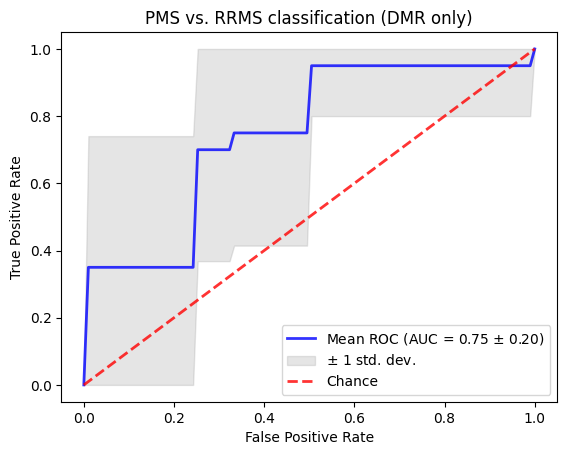

In [6]:
f = plt.figure()
plt.plot(MEAN_FPR, mean_tpr_pvr_dmr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_pvr_dmr, std_auc_pvr_dmr),
         lw=2, alpha=.8)
std_tpr = np.std(tprs_pvr_dmr, axis=0)
plt.fill_between(MEAN_FPR, np.maximum(mean_tpr_pvr_dmr - std_tpr, 0),
                 np.minimum(mean_tpr_pvr_dmr + std_tpr, 1),
                 color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('PMS vs. RRMS classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.legend(loc="lower right"); plt.show()


## TOO only (Progressive MS vs. RRMS)

In [7]:
# PMS vs. RRMS — TOO only (SVM RBF C=4, class_weight='balanced')
# Fixed 9 cell-type features (TOO_IDX), no per-fold feature selection
tprs_pvr_too, aucs_pvr_too = [], []

for fold_i in range(10):
    tr_names, tr_labels = load_fold_samples(os.path.join(FOLD_DIR_PVR,
        f"progressive_vs_rrms_table_design_matrix.bin.v2.training.fold{fold_i:02d}"))
    te_names, te_labels = load_fold_samples(os.path.join(FOLD_DIR_PVR,
        f"progressive_vs_rrms_table_design_matrix.bin.v2.testing.fold{fold_i:02d}"))
    tr_sn = [short_name(s) for s in tr_names if short_name(s) in too_dict]
    te_sn = [short_name(s) for s in te_names if short_name(s) in too_dict]
    tr_labels = tr_labels[[i for i, s in enumerate(tr_names) if short_name(s) in too_dict]]
    te_labels = te_labels[[i for i, s in enumerate(te_names) if short_name(s) in too_dict]]

    X_train = np.array([too_dict[n] for n in tr_sn], dtype='float32')[:, TOO_IDX]
    X_test  = np.array([too_dict[n] for n in te_sn], dtype='float32')[:, TOO_IDX]

    clf = svm.SVC(C=4, kernel='rbf', probability=True, class_weight='balanced',
                  random_state=random_state)
    clf.fit(X_train, tr_labels)
    prob = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(te_labels, prob)
    tprs_pvr_too.append(np.interp(MEAN_FPR, fpr, tpr)); tprs_pvr_too[-1][0] = 0.0
    aucs_pvr_too.append(auc(fpr, tpr))

mean_tpr_pvr_too = np.nanmean(tprs_pvr_too, axis=0); mean_tpr_pvr_too[-1] = 1.0
mean_auc_pvr_too = auc(MEAN_FPR, mean_tpr_pvr_too)
std_auc_pvr_too  = np.std(aucs_pvr_too)
print(f"PMS vs RRMS TOO: mean AUC = {mean_auc_pvr_too:.3f} +/- {std_auc_pvr_too:.3f}")


PMS vs RRMS TOO: mean AUC = 0.686 +/- 0.228


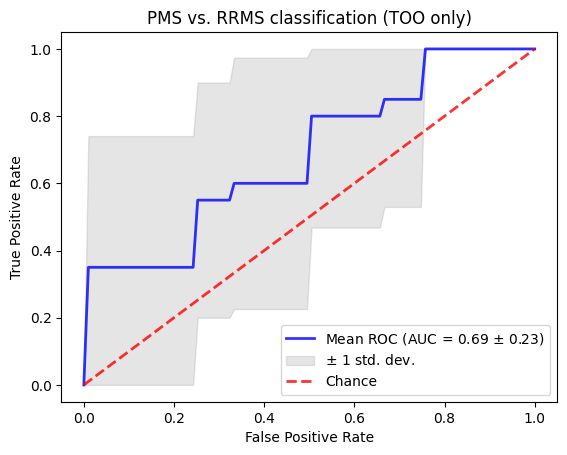

In [8]:
f = plt.figure()
plt.plot(MEAN_FPR, mean_tpr_pvr_too, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_pvr_too, std_auc_pvr_too),
         lw=2, alpha=.8)
std_tpr = np.std(tprs_pvr_too, axis=0)
plt.fill_between(MEAN_FPR, np.maximum(mean_tpr_pvr_too - std_tpr, 0),
                 np.minimum(mean_tpr_pvr_too + std_tpr, 1),
                 color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('PMS vs. RRMS classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.legend(loc="lower right"); plt.show()


# Active relapse RRMS vs. Stable remission RRMS

## DMR only (Active relapse RRMS vs. Stable remission RRMS)

In [10]:
# A-RRMS vs. S-RRMS — DMR only (TruncatedSVD(3) + SVM RBF C=0.1)
# avs_fold_dmr stores SVD-transformed DMR features per fold for use in DMR+TOO cell
avs_fold_dmr = {}
tprs_avs_dmr, aucs_avs_dmr = [], []

for fold_i in range(10):
    tr_names, tr_labels = load_fold_samples(os.path.join(FOLD_DIR_AVS,
        f"active_vs_stable_table_design_matrix.bin.v2.training.fold{fold_i:02d}"))
    te_names, te_labels = load_fold_samples(os.path.join(FOLD_DIR_AVS,
        f"active_vs_stable_table_design_matrix.bin.v2.testing.fold{fold_i:02d}"))
    tr_keep = [s in full_to_idx for s in tr_names]
    te_keep = [s in full_to_idx for s in te_names]
    tr_cols   = np.array([full_to_idx[s] for s in tr_names if s in full_to_idx])
    te_cols   = np.array([full_to_idx[s] for s in te_names if s in full_to_idx])
    tr_labels = tr_labels[tr_keep]; te_labels = te_labels[te_keep]
    tr_names  = [s for s in tr_names if s in full_to_idx]
    te_names  = [s for s in te_names if s in full_to_idx]

    dmr_rows = get_dmr_row_indices(os.path.join(FOLD_DIR_AVS,
        f"dmrs.active_vs_stable.fold{fold_i:02d}.adjusted.bed"))
    rows = np.array(dmr_rows)
    X_train = methy_mat[rows, :][:, tr_cols].T
    X_test  = methy_mat[rows, :][:, te_cols].T

    svd = TruncatedSVD(n_components=3, random_state=random_state)
    X_train_svd = svd.fit_transform(X_train)
    X_test_svd  = svd.transform(X_test)

    clf = svm.SVC(kernel='rbf', probability=True, gamma='scale', C=0.1,
                  random_state=random_state)
    clf.fit(X_train_svd, tr_labels)
    prob = clf.predict_proba(X_test_svd)[:, 1]
    print(f"  fold {fold_i}: {len(dmr_rows)} DMR regions")

    avs_fold_dmr[fold_i] = {
        'tr_labels': tr_labels, 'te_labels': te_labels,
        'tr_names': tr_names,   'te_names': te_names,
        'dmr_X_train': X_train_svd,
        'dmr_X_test':  X_test_svd,
    }

    fpr, tpr, _ = roc_curve(te_labels, prob)
    tprs_avs_dmr.append(np.interp(MEAN_FPR, fpr, tpr)); tprs_avs_dmr[-1][0] = 0.0
    aucs_avs_dmr.append(auc(fpr, tpr))

mean_tpr_avs_dmr = np.nanmean(tprs_avs_dmr, axis=0); mean_tpr_avs_dmr[-1] = 1.0
mean_auc_avs_dmr = auc(MEAN_FPR, mean_tpr_avs_dmr)
std_auc_avs_dmr  = np.std(aucs_avs_dmr)
print(f"\nA-RRMS vs S-RRMS DMR: mean AUC = {mean_auc_avs_dmr:.3f} +/- {std_auc_avs_dmr:.3f}")


  fold 0: 102 DMR regions
  fold 1: 156 DMR regions
  fold 2: 198 DMR regions
  fold 3: 199 DMR regions
  fold 4: 178 DMR regions
  fold 5: 183 DMR regions
  fold 6: 125 DMR regions
  fold 7: 163 DMR regions
  fold 8: 162 DMR regions
  fold 9: 114 DMR regions

A-RRMS vs S-RRMS DMR: mean AUC = 0.945 +/- 0.150


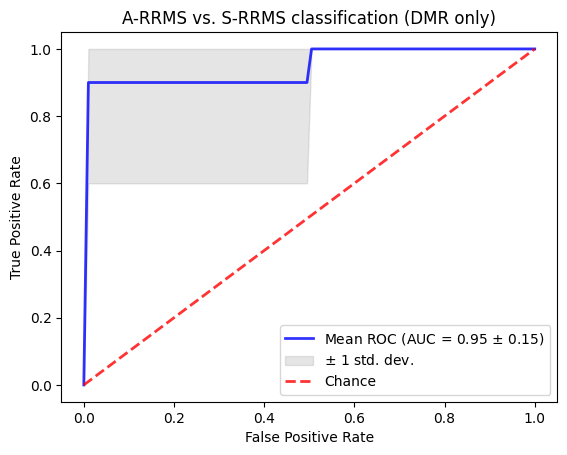

In [11]:
f = plt.figure()
plt.plot(MEAN_FPR, mean_tpr_avs_dmr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_avs_dmr, std_auc_avs_dmr),
         lw=2, alpha=.8)
std_tpr = np.std(tprs_avs_dmr, axis=0)
plt.fill_between(MEAN_FPR, np.maximum(mean_tpr_avs_dmr - std_tpr, 0),
                 np.minimum(mean_tpr_avs_dmr + std_tpr, 1),
                 color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('A-RRMS vs. S-RRMS classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.legend(loc="lower right"); plt.show()


## TOO only (Active relapse RRMS vs. Stable remission RRMS)

In [12]:
# A-RRMS vs. S-RRMS — TOO only (LogisticRegression L2 C=100)
# Fixed 9 cell-type features (TOO_IDX), no per-fold feature selection
tprs_avs_too, aucs_avs_too = [], []

for fold_i in range(10):
    tr_names, tr_labels = load_fold_samples(os.path.join(FOLD_DIR_AVS,
        f"active_vs_stable_table_design_matrix.bin.v2.training.fold{fold_i:02d}"))
    te_names, te_labels = load_fold_samples(os.path.join(FOLD_DIR_AVS,
        f"active_vs_stable_table_design_matrix.bin.v2.testing.fold{fold_i:02d}"))
    tr_sn = [short_name(s) for s in tr_names if short_name(s) in too_dict]
    te_sn = [short_name(s) for s in te_names if short_name(s) in too_dict]
    tr_labels = tr_labels[[i for i, s in enumerate(tr_names) if short_name(s) in too_dict]]
    te_labels = te_labels[[i for i, s in enumerate(te_names) if short_name(s) in too_dict]]

    X_train = np.array([too_dict[n] for n in tr_sn], dtype='float32')[:, TOO_IDX]
    X_test  = np.array([too_dict[n] for n in te_sn], dtype='float32')[:, TOO_IDX]

    clf = LogisticRegression(penalty='l2', C=100, class_weight='balanced',
                              solver='lbfgs', max_iter=100, random_state=random_state)
    clf.fit(X_train, tr_labels)
    prob = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(te_labels, prob)
    tprs_avs_too.append(np.interp(MEAN_FPR, fpr, tpr)); tprs_avs_too[-1][0] = 0.0
    aucs_avs_too.append(auc(fpr, tpr))

mean_tpr_avs_too = np.nanmean(tprs_avs_too, axis=0); mean_tpr_avs_too[-1] = 1.0
mean_auc_avs_too = auc(MEAN_FPR, mean_tpr_avs_too)
std_auc_avs_too  = np.std(aucs_avs_too)
print(f"A-RRMS vs S-RRMS TOO: mean AUC = {mean_auc_avs_too:.3f} +/- {std_auc_avs_too:.3f}")


A-RRMS vs S-RRMS TOO: mean AUC = 0.724 +/- 0.247


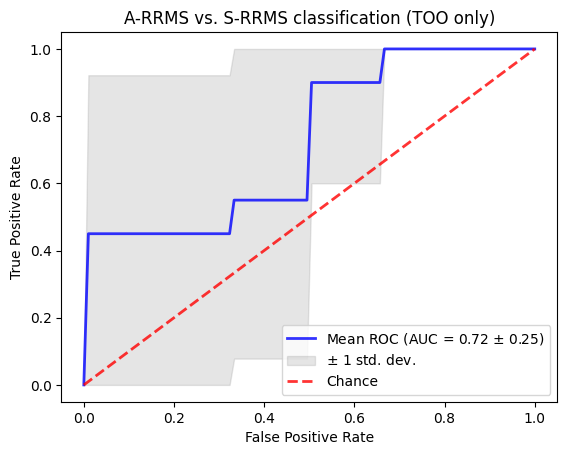

In [13]:
f = plt.figure()
plt.plot(MEAN_FPR, mean_tpr_avs_too, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc_avs_too, std_auc_avs_too),
         lw=2, alpha=.8)
std_tpr = np.std(tprs_avs_too, axis=0)
plt.fill_between(MEAN_FPR, np.maximum(mean_tpr_avs_too - std_tpr, 0),
                 np.minimum(mean_tpr_avs_too + std_tpr, 1),
                 color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('A-RRMS vs. S-RRMS classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)
plt.legend(loc="lower right"); plt.show()


# Severe vs. Mild

## DMR only (Severe vs. Mild)

In [902]:
##get label dict and matrix from TOO
training_sample_label_dict=dict()
testing_sample_label_dict=dict()

training_sample_too_mat_dict=dict()
testing_sample_too_mat_dict=dict()

training_sample_group_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/pdds_severe_vs_mild_table_design_matrix.pdds_collect_in_10days.bin.training.fold0' + str(fold)
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/pdds_severe_vs_mild_table_design_matrix.pdds_collect_in_10days.bin.testing.fold0' + str(fold)
    training_label_list=[]
    training_group_list=[]
    training_too_mat=[]
    with open(training_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            training_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            training_too_mat.append(too_list)
            group_list=sample_group_dict[sample_name]
            training_group_list.append(group_list)
    training_label_list=np.array(training_label_list,dtype='int32')
    training_sample_label_dict[fold]=training_label_list
    training_too_mat = np.array(training_too_mat,dtype='float32')
    training_sample_too_mat_dict[fold] = training_too_mat
    training_group_list=np.array(training_group_list,dtype='int32')
    training_sample_group_dict[fold]=training_group_list
    
    testing_label_list=[]
    testing_too_mat=[]
    with open(testing_f_name,'r') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            if splitline[1] == 'base':
                continue
            testing_label_list.append(splitline[3])
            sample_name = splitline[0]
            too_list = too_mat_dict[sample_name]
            testing_too_mat.append(too_list)
    testing_label_list=np.array(testing_label_list,dtype='int32')
    testing_sample_label_dict[fold]=testing_label_list
    testing_too_mat = np.array(testing_too_mat,dtype='float32')
    testing_sample_too_mat_dict[fold] = testing_too_mat
    



##get sample matrix dict

training_sample_mat_dict=dict()
testing_sample_mat_dict=dict()

for fold in range(10):
    training_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/dmrs.pdds_severe_vs_mild.filtered.training.fold0' + str(fold) + '.add_value.methy.bed.gz'
    testing_f_name = '/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/dmrs.pdds_severe_vs_mild.filtered.testing.fold0' + str(fold) + '.add_value.methy.bed.gz'
    training_mat_list=[]
    with gzip.open(training_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            training_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                training_mat_pos.append(m)
            training_mat_pos = np.array(training_mat_pos,dtype='float32')
            training_mat_list.append(training_mat_pos)
    training_mat_list=np.array(training_mat_list,dtype='float32')
    training_sample_mat_dict[fold]=np.nan_to_num(training_mat_list)
    testing_mat_list=[]
    with gzip.open(testing_f_name,'rt') as f:
        for line in f:
            line=line.rstrip('\n')
            splitline = line.split("\t")
            testing_mat_pos=[]
            for i in range(6,len(splitline),2):
                j=i+1
                if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                    m = np.nan
                else:
                    m = float(splitline[i])/float(splitline[j])
                testing_mat_pos.append(m)
            testing_mat_pos = np.array(testing_mat_pos,dtype='float32')
            testing_mat_list.append(testing_mat_pos)
    testing_mat_list=np.array(testing_mat_list,dtype='float32')
    testing_sample_mat_dict[fold]=np.nan_to_num(testing_mat_list)



/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yapin

0.75
1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


...

/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)
/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))
/Users/yaping/opt/anaconda3/envs/base_env3/lib/python3.8/site-packages/xgboost/core.py:160: UserWarning: [12:24:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:742: 
Parameters: { "class_weight" } are not used.

  warnings.warn(smsg, UserWarning)


0.5
1.0
1.0


/var/folders/0r/8bdyzp4x5bn3psm8zddb_d_h0000gn/T/ipykernel_39648/510203208.py:46: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  tprs.append(interp(mean_fpr, fpr, tpr))


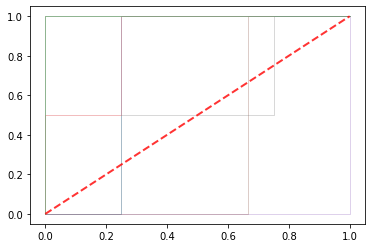

In [774]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm
from sklearn.base import clone
from sklearn.decomposition import TruncatedSVD


random_state=42




tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)


for i in range(10):

    train_dmr_X = training_sample_mat_dict[i].transpose()   
    train_y = training_sample_label_dict[i]
    
    test_dmr_X = testing_sample_mat_dict[i].transpose()   
    test_y = testing_sample_label_dict[i]
    
    random_state_i = random_state + i
    
    classifier = xgboost.XGBClassifier(max_depth=3, learning_rate=0.4, n_estimators=1000, class_weight='balanced', objective='binary:logistic',subsample=0.667,n_jobs=4)

    classifier.fit(train_dmr_X, train_y)

    final_prob_test = classifier.predict_proba(test_dmr_X)[:, 1]

    # Compute ROC curve and area the curve
    fpr, tpr, thresholds = roc_curve(test_y, final_prob_test)
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



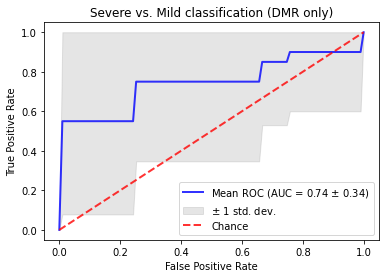

In [775]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild classification (DMR only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/classification/pdds_severe_vs_mild_v3/performance_model.pdds_severe_vs_mild_v3_CV.xgboost.pdf", bbox_inches='tight')


## TOO only (Severe vs. Mild)

(40, 8)
0.375
(42, 6)
1.0
(42, 6)
1.0
(40, 6)
0.5
(42, 5)
1.0
(42, 6)
0.6666666666666667
(42, 7)
1.0
(40, 4)
1.0
(42, 5)
1.0
(42, 5)
0.6666666666666667


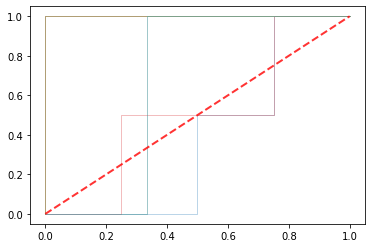

In [1000]:
from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from scipy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
import xgboost
import lightgbm

random_state=42
cv = StratifiedKFold(n_splits=10)
#index = [2,3,4,5,6,12,22,23,30]
#index = [4,8,11,13,29,31]
index = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,18,20,21,24,30,31,33,35]

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for i in range(10):
    train_X = training_sample_too_mat_dict[i][:,index]
    train_y = training_sample_label_dict[i]
    
    test_X = testing_sample_too_mat_dict[i][:,index]
    test_y = testing_sample_label_dict[i]

    classifier = GradientBoostingClassifier(n_estimators=200, learning_rate=0.15, max_depth=2, random_state=random_state,min_samples_split=2,min_samples_leaf=2,subsample=0.8,max_features='log2')
    
    n_features = train_X.shape[1]
    # Step A: For each feature, do a one-sided Mann–Whitney on the training fold
    pvals = []
    significance_mask = np.zeros(n_features, dtype=bool)
    for col in range(n_features):
        col_values = train_X[:, col]
        sig, pval = is_significant_one_sided(col_values, train_y, 0.1)
        pvals.append(pval)
        if sig:
            significance_mask[col] = True

    # Step B: If no feature passed p<0.05, pick the best feature (lowest p)
    if not significance_mask.any():
        # fallback: pick the single best feature
        best_col = np.argmin(pvals)
        significance_mask[best_col] = True

    #significance_mask=ms_control_too_mask_dict[i]
    train_X_sel = train_X[:, significance_mask]
    test_X_sel  = test_X[:, significance_mask]
    
    print(train_X_sel.shape)
    classifier.fit(train_X_sel, train_y)

    # Step D: Predict probabilities, get ROC
    probas_ = classifier.predict_proba(test_X_sel)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    # store tpr after interpolation
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    print(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label=f'Fold {i} (AUC={roc_auc:.2f})')
    i += 1
    
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)




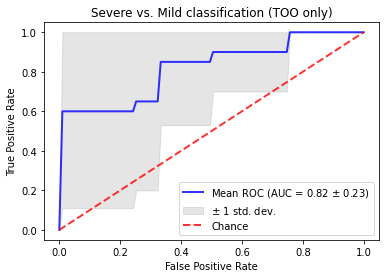

In [1001]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild classification (TOO only)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)
plt.legend(loc="lower right")
plt.show()
f.savefig("/Users/yaping/Documents/workspace/projects/ms_wgbs/too/performance_model.too_diff_neuron_immune_in_ms_control.pdds_severe_vs_mild_v3_CV.gbt.pdf", bbox_inches='tight')





# Prognostic prediction after correct with disease duration

## time 1000 (prognostic)

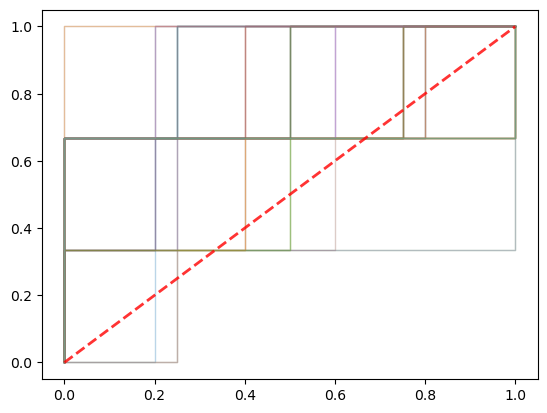

In [108]:
severe_vs_mild_time0_matrix=[]
severe_vs_mild_time0_labels=[]


with gzip.open('/Users/xfj2191/Documents/workspace/projects/ms_cfdna_wgbs/progression/corrected_covar.with_disease_duration_pdds_followup.location_fdr001_model.tim1000.add_methy.bed.gz','rt') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        mat_pos=[]
        for i in range(6,len(splitline),2):
            j=i+1
            if math.isclose(float(splitline[j]), 0, abs_tol=1e-9):
                m = np.nan
            else:
                m = float(splitline[i])/float(splitline[j])
            mat_pos.append(m)
        mat_pos = np.array(mat_pos,dtype='float32')
        severe_vs_mild_time0_matrix.append(mat_pos)
severe_vs_mild_time0_matrix = np.array(severe_vs_mild_time0_matrix,dtype='float32')
severe_vs_mild_time0_matrix = np.nan_to_num(severe_vs_mild_time0_matrix)
severe_vs_mild_time0_matrix = np.transpose(severe_vs_mild_time0_matrix)

with open('/Users/xfj2191/Documents/workspace/projects/ms_cfdna_wgbs/progression/pdds.data.inter.tim1000.txt','r') as f:
    for line in f:
        line=line.rstrip('\n')
        splitline = line.split("\t")
        severe_vs_mild_time0_labels.append(int(splitline[3]))
        sample_name = splitline[0]


severe_vs_mild_time0_labels = np.array(severe_vs_mild_time0_labels,dtype='int32')

from scipy import stats
from sklearn.feature_selection import RFECV
from sklearn import svm, datasets
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, KFold, LeaveOneOut,cross_val_score
from numpy import interp
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import GradientBoostingClassifier
#from lightgbm import LGBMClassifier
import xgboost
#import lightgbm

random_state=42
cv = RepeatedStratifiedKFold(n_splits=5,n_repeats=10, random_state=random_state)
X = severe_vs_mild_time0_matrix
y = severe_vs_mild_time0_labels

svd = TruncatedSVD(n_components=20, random_state=random_state)

classifier = LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=0.1, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=None)
#classifier = svm.SVC(kernel='rbf', probability=True,random_state=random_state)
#classifier = xgboost.XGBClassifier(max_depth=3, learning_rate=0.1, n_estimators=100, class_weight='balanced', objective='binary:logistic',subsample=0.667,n_jobs=4)
#classifier = svm.SVC(C=1.0, kernel='linear', gamma='scale', coef0=0.0, shrinking=True, probability=True, tol=0.001, cache_size=200, class_weight='balanced', verbose=False, max_iter=-1, decision_function_shape='ovr', random_state=None)
#classifier = LogisticRegression(penalty='elasticnet', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight='balanced', random_state=random_state, solver='saga', max_iter=1000, multi_class='auto', verbose=0, warm_start=False, n_jobs=-1, l1_ratio=0.1)
#classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=random_state,min_samples_split=2,min_samples_leaf=1,subsample=0.8,max_features='log2')
#classifier = LGBMClassifier(n_estimators=200,learning_rate=0.1,num_leaves=31,max_depth=-1,reg_alpha=0.1,reg_lambda=0.1,subsample=0.8, colsample_bytree=0.8,min_child_samples=10)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

i = 0
for train, test in cv.split(X, y):
    train_X = X[train]
    train_y = y[train]
    test_X = X[test]
    test_y = y[test]
    train_X_svd=svd.fit_transform(train_X)
    test_X_svd=svd.transform(test_X)
    #min_features_to_select = 1  # Minimum number of features to consider
    #rfecv = RFECV(
    #    estimator=classifier,
    #    step=1,
    #    cv=cv,
    #    scoring='accuracy',
    #    min_features_to_select=min_features_to_select,
    #    n_jobs=-1,
    #)
    #rfecv.fit(train_X, train_y)
    #print("Number of features selected:", rfecv.n_features_)

    #probas_ = classifier.fit(train_X[:,rfecv.support_], train_y).predict_proba(test_X[:,rfecv.support_])
    # Compute ROC curve and area the curve
    probas_ = classifier.fit(train_X_svd, train_y).predict_proba(test_X_svd)
    fpr, tpr, thresholds = roc_curve(test_y, probas_[:, 1])
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    plt.plot(fpr, tpr, lw=1, alpha=0.3,
             label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

    i += 1
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Chance', alpha=.8)

mean_tpr = np.nanmean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)



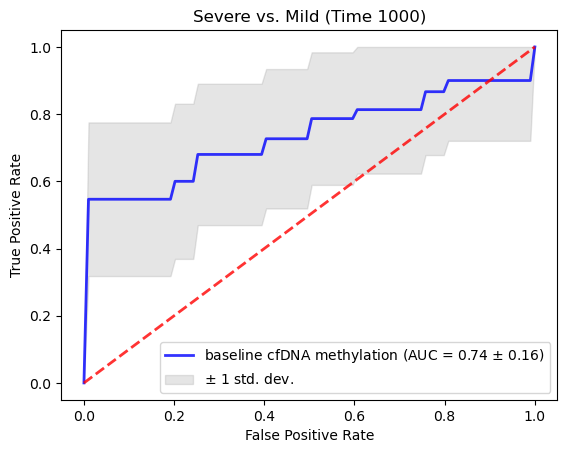

In [110]:
f = plt.figure()
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'baseline cfDNA methylation (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                 label=r'$\pm$ 1 std. dev.')

plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Severe vs. Mild (Time 1000 days)')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
          alpha=.8)
plt.legend(loc="lower right")
plt.show()

f.savefig("/Users/xfj2191/Documents/workspace/projects/ms_cfdna_wgbs/progression/performance_model.progression_time1000.corrected_covar.with_disease_duration_pdds_followup.pdds_severe_vs_mild_CV.gbt.pdf", bbox_inches='tight')
